# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model](https://open.spotify.com/track/4R3AU2pjv8ge2siX1fVbZs?si=b2712f32da0e4358) or a simple [linear regression model](https://scikit-learn.org/stable/modules/linear_model.html)
        - An advanced regressor of your choice (e.g., Random Forest, Neural Network, etc.)

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Assuming that the files `adult.data` and `adult.test` are in `../data/adult/`, then you can use the code below to load them.

In [157]:
import pandas as pd
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', skiprows = 1, names = columns))


fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [158]:
fires_dt.dtypes

coord_x      int64
coord_y      int64
month       object
day         object
ffmc       float64
dmc        float64
dc         float64
isi        float64
temp       float64
rh           int64
wind       float64
rain       float64
area       float64
dtype: object

# Get X and Y

Create the features data frame and target data.

In [159]:
from sklearn.model_selection import train_test_split

X = fires_dt.drop('area', axis = 1)
y = fires_dt['area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

X.shape

(517, 12)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [160]:
# preproc1
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features_1 = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features_1 = ['month', 'day']


preproc1 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_1),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_1)
])

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [161]:
# preproc2
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer, RobustScaler


nonlinear_feature = ['rain','ffmc', 'dmc', 'dc']
numeric_features_2 = ['coord_x', 'coord_y', 'isi', 'temp', 'rh', 'wind']
categorical_features_2 = ['month', 'day']


preproc2 = ColumnTransformer(transformers=[
    #('quantile_transform', QuantileTransformer(n_quantiles = 10), nonlinear_feature),
    ('nonlinear', RobustScaler(), nonlinear_feature),
    ('num', StandardScaler(), numeric_features_2),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_2)
])


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [162]:
# Pipeline A = preproc1 + baseline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelpipeline_A = Pipeline(steps=[('preprocessing', preproc1),
                                  ('regressor', LinearRegression())])

modelpipeline_A


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [163]:
# Pipeline B = preproc2 + baseline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

modelpipeline_B = Pipeline(steps=[('preprocessing', preproc2),
                                  ('regressor', LinearRegression())])

modelpipeline_B


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nonlinear', RobustScaler(),
                                                  ['rain', 'ffmc', 'dmc',
                                                   'dc']),
                                                 ('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'isi',
                                                   'temp', 'rh', 'wind']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [164]:
# Pipeline C = preproc1 + advanced model
from sklearn.ensemble import RandomForestRegressor

modelpipeline_C = Pipeline(steps=[('preprocessing', preproc1),
                                  ('regressor', RandomForestRegressor())])

modelpipeline_C

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor())])

In [165]:
# Pipeline D = preproc2 + advanced model
from sklearn.ensemble import RandomForestRegressor

modelpipeline_D = Pipeline(steps=[('preprocessing', preproc2),
                                  ('regressor', RandomForestRegressor())])

modelpipeline_D


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nonlinear', RobustScaler(),
                                                  ['rain', 'ffmc', 'dmc',
                                                   'dc']),
                                                 ('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'isi',
                                                   'temp', 'rh', 'wind']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor())])

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [166]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False]
}

grid_search = GridSearchCV(estimator=modelpipeline_A, param_grid=param_grid, cv=5)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model_A = grid_search.best_estimator_
test_score_A = best_model_A.score(X_test, y_test)
print("Test set score of modelpipeline_A: ", test_score_A)

Best parameters found:  {'regressor__fit_intercept': False, 'regressor__positive': True}
Best cross-validation score:  -0.17801414769481236
Test set score of modelpipeline_A:  0.0056157222139719964


In [167]:

param_grid = {
    'regressor__fit_intercept': [True, False],
    'regressor__positive': [True, False]
}

grid_search = GridSearchCV(estimator=modelpipeline_B, param_grid=param_grid, cv=5)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model_B = grid_search.best_estimator_
test_score_B = best_model_B.score(X_test, y_test)
print("Test set score of modelpipeline_B: ", test_score_B)

Best parameters found:  {'regressor__fit_intercept': False, 'regressor__positive': True}
Best cross-validation score:  -0.1774987822935643
Test set score of modelpipeline_B:  0.0055818839080933325


In [168]:

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(estimator=modelpipeline_C, param_grid=param_grid, cv=5)

grid_search.fit(X_train, y_train)


print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model_C = grid_search.best_estimator_
test_score_C = best_model_C.score(X_test, y_test)
print("Test set score of modelpipeline_C: ", test_score_C)

Best parameters found:  {'regressor__max_depth': 20, 'regressor__n_estimators': 200}
Best cross-validation score:  -0.6659771672693375
Test set score of modelpipeline_C:  -0.08837394573335833


In [169]:

param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20]
}

grid_search = GridSearchCV(estimator=modelpipeline_D, param_grid=param_grid, cv=5)

grid_search.fit(X_train, y_train)


print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

best_model_D = grid_search.best_estimator_
test_score_D = best_model_D.score(X_test, y_test)
print("Test set score of modelpipeline_D: ", test_score_D)

Best parameters found:  {'regressor__max_depth': 20, 'regressor__n_estimators': 100}
Best cross-validation score:  -0.6759155583135954
Test set score of modelpipeline_D:  -0.09268703907033515


In [171]:
print("Test set score of modelpipeline_A: ", test_score_A)
print("Test set score of modelpipeline_B: ", test_score_B)
print("Test set score of modelpipeline_C: ", test_score_C)
print("Test set score of modelpipeline_D: ", test_score_D)

Test set score of modelpipeline_A:  0.0056157222139719964
Test set score of modelpipeline_B:  0.0055818839080933325
Test set score of modelpipeline_C:  -0.08837394573335833
Test set score of modelpipeline_D:  -0.09268703907033515


# Evaluate

+ Which model has the best performance?

According to the score, the model B has the best performance.  Eventhough the score is close to zero but still better than model C and D

# Export

+ Save the best performing model to a pickle file.

In [172]:
import pickle

with open('best_model_B.pkl', 'wb') as f:
    pickle.dump(best_model_B, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.


    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?


In [173]:
import shap
best_model_B.fit(X_train, y_train)

data_transform = best_model_B.named_steps['preprocessing'].transform(X_test)

explainer = shap.explainers.Linear(
    best_model_B.named_steps['regressor'], 
    data_transform,
    feature_names = best_model_B.named_steps['preprocessing'].get_feature_names_out())

shap_values = explainer(data_transform)

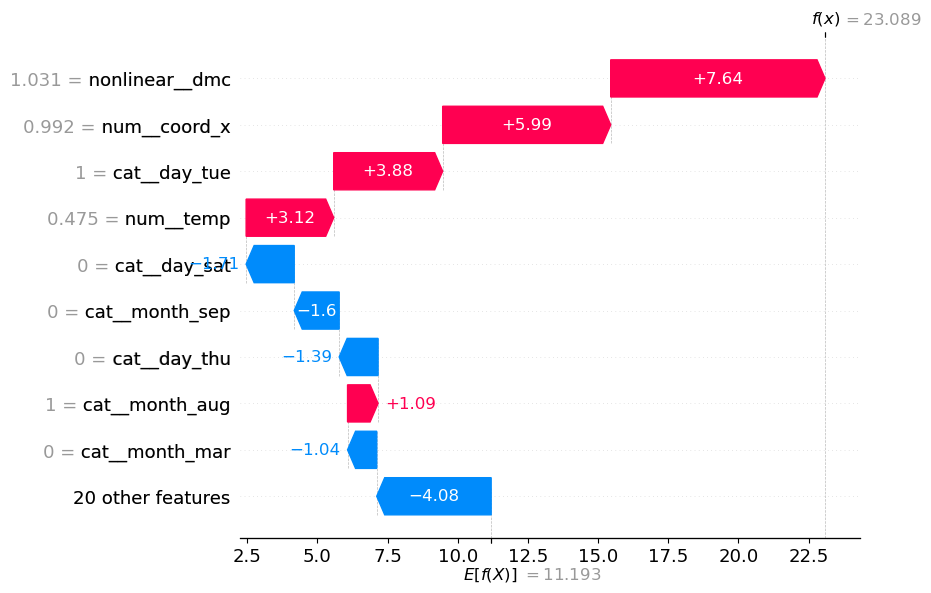

In [174]:
shap.plots.waterfall(shap_values[1])

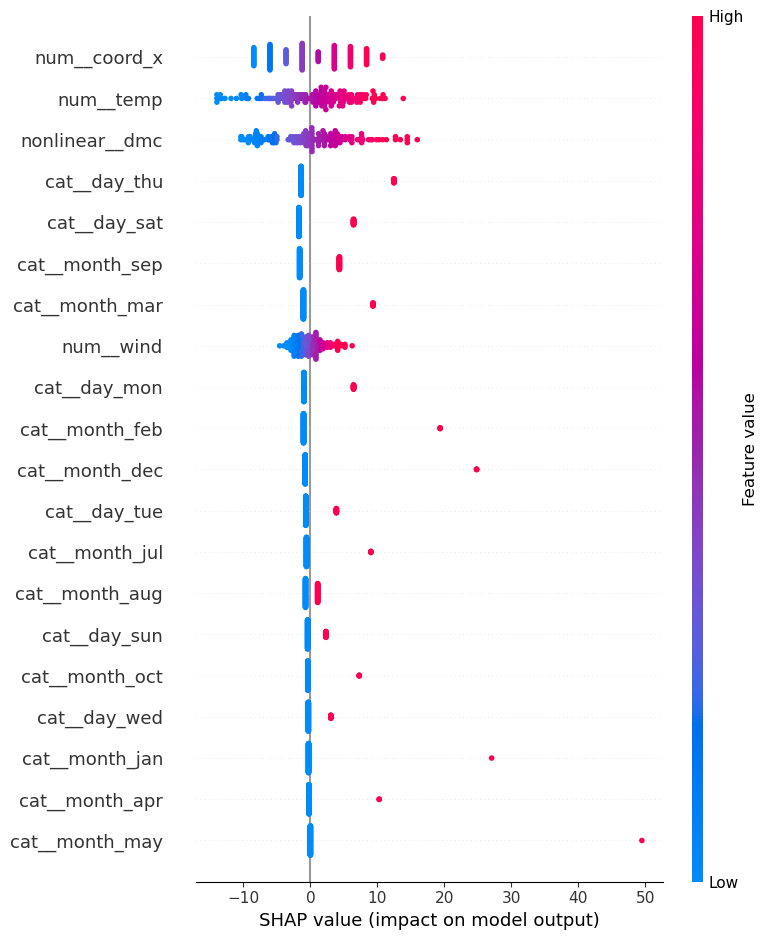

In [175]:
shap.summary_plot(shap_values, features=data_transform, feature_names=best_model_B.named_steps['preprocessing'].get_feature_names_out())

*(Answer here.)*

From the summary plot of feature importance, the following insights can be derived:

Most Important Features:

- num__coord_x: This feature shows a significant impact on the model's output, with high SHAP values.
- num__temp: This feature also has a substantial influence on the model's predictions.
- nonlinear__dmc: This feature contributes significantly to the predictions.
- cat__day_thu: This feature shows a notable impact on the model's predictions.

Least Important Features:

- Features like cat__month_apr, cat__month_may, and several other categorical month features show minimal impact on the model's predictions, as indicated by the SHAP values clustering around zero.

Based on the SHAP summary plot, I would consider removing features that have minimal or no impact on the model's predictions, such as cat__month_apr, cat__month_may, and other categorical month features with low SHAP values.  These features show minimal contribution to the model's predictions, and removing them can simplify the model without significantly affecting performance.

After removal, I will retrain the model on the training set and evaluate it on the test set; compare performance metrics before and after removing the features. Then use cross-validation to ensure the changes in model performance are consistent across different subsets of the data.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.